# 02. Сравнение моделей: Baseline vs LightGBM

В этом ноутбуке:
1. Загружаем данные и делим на train/val/test.
2. Обучаем baseline — Logistic Regression на стандартизованных числовых + one-hot категориальных признаках.
3. Обучаем улучшенную модель — LightGBM с class_weight='balanced'.
4. Сравниваем по ROC-AUC, PR-AUC, KS, F1.
5. Строим ROC и PR кривые.
6. Смотрим важность признаков LightGBM.

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from sklearn.metrics import roc_curve, precision_recall_curve

from src.utils.config import TrainConfig
from src.data.dataset import load_dataset, split_dataset, NUMERIC_FEATURES, CATEGORICAL_FEATURES
from src.models.baseline import build_baseline_pipeline
from src.models.improved import build_improved_pipeline
from src.models.metrics import evaluate

cfg = TrainConfig.load()
df = load_dataset(cfg)
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(df, cfg)
print(X_train.shape, X_val.shape, X_test.shape)

2026-05-26 13:08:41 | INFO    | src.data.dataset | Loading dataset from /Users/v.razon/Desktop/вуз/ml/mirea-aie-project/project/data/raw/application_train.csv


2026-05-26 13:08:41 | INFO    | src.data.dataset | Loaded 50000 rows; positive rate = 0.0604


2026-05-26 13:08:41 | INFO    | src.data.dataset | Split: train=35000, val=5000, test=10000 (positive rates: 0.060 / 0.060 / 0.060)


(35000, 23) (5000, 23) (10000, 23)


In [2]:
baseline = build_baseline_pipeline(**cfg.baseline.params, random_state=cfg.data.random_state)
baseline.fit(X_train, y_train)
val_proba_b = baseline.predict_proba(X_val)[:, 1]
m_b = evaluate(y_val, val_proba_b)
m_b.as_dict()

{'roc_auc': 0.769384745939515,
 'pr_auc': 0.17755805958210502,
 'f1_at_threshold': 0.2204724409448819,
 'ks_statistic': 0.43965728688268085,
 'log_loss': 0.5621762326659635,
 'brier': 0.1916241208444276,
 'threshold': 0.5}

In [3]:
improved = build_improved_pipeline(**cfg.improved.params, random_state=cfg.data.random_state)
improved.fit(X_train, y_train)
val_proba_i = improved.predict_proba(X_val)[:, 1]
m_i = evaluate(y_val, val_proba_i)
m_i.as_dict()

{'roc_auc': 0.7355017916599709,
 'pr_auc': 0.16301253703985963,
 'f1_at_threshold': 0.22450728363324765,
 'ks_statistic': 0.37958240649113756,
 'log_loss': 0.38431659264179746,
 'brier': 0.12318706941581649,
 'threshold': 0.5}

In [4]:
comparison = pd.DataFrame({
    'baseline (logreg)': m_b.as_dict(),
    'improved (lightgbm)': m_i.as_dict(),
})
comparison

,baseline (logreg),improved (lightgbm)
roc_auc,0.769385,0.735502
pr_auc,0.177558,0.163013
f1_at_threshold,0.220472,0.224507
ks_statistic,0.439657,0.379582
log_loss,0.562176,0.384317
brier,0.191624,0.123187
threshold,0.500000,0.500000


## ROC и PR кривые на val

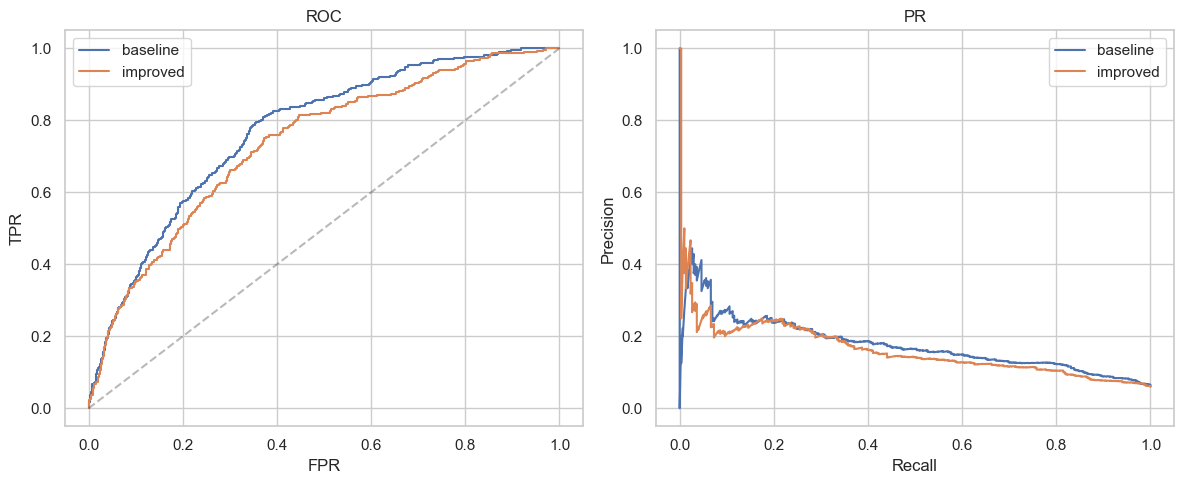

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, proba in [('baseline', val_proba_b), ('improved', val_proba_i)]:
    fpr, tpr, _ = roc_curve(y_val, proba)
    axes[0].plot(fpr, tpr, label=name)
    prec, rec, _ = precision_recall_curve(y_val, proba)
    axes[1].plot(rec, prec, label=name)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('PR')
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()

## Важность признаков LightGBM

LightGBM умеет считать `feature_importance`. Свяжем её с именами признаков после one-hot.

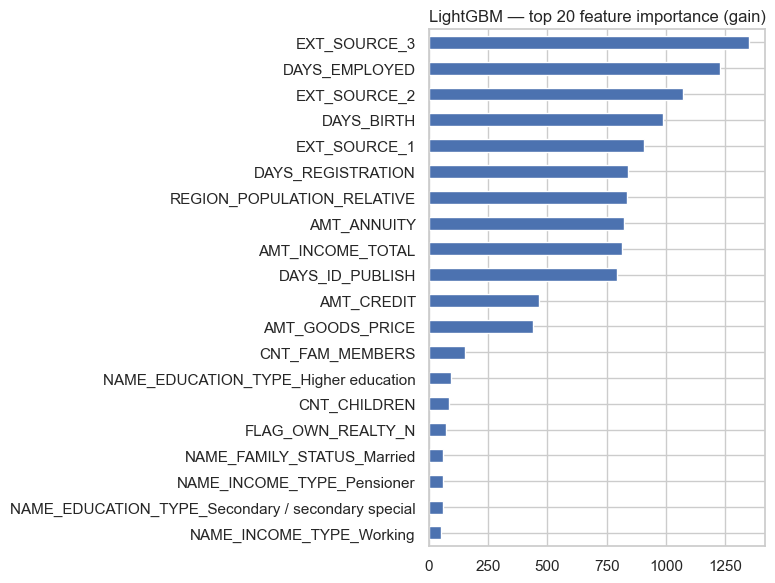

In [6]:
pre = improved.named_steps['preprocessor']
clf = improved.named_steps['classifier']
feat_names = pre.get_feature_names_out()
imp = pd.Series(clf.feature_importances_, index=feat_names).sort_values(ascending=False)
imp.head(20).iloc[::-1].plot.barh(figsize=(8, 6))
plt.title('LightGBM — top 20 feature importance (gain)'); plt.tight_layout(); plt.show()

## Финальная модель — на тестовой выборке

Выбираем модель с большим ROC-AUC на val и считаем итоговые метрики на отложенном тесте.

In [7]:
final = improved if m_i.roc_auc >= m_b.roc_auc else baseline
final_name = 'improved (lightgbm)' if final is improved else 'baseline (logreg)'
test_proba = final.predict_proba(X_test)[:, 1]
m_test = evaluate(y_test, test_proba)
print('Selected:', final_name)
m_test.as_dict()

Selected: baseline (logreg)


{'roc_auc': 0.7793009001998878,
 'pr_auc': 0.2174712865966456,
 'f1_at_threshold': 0.22744895321788575,
 'ks_statistic': 0.4351837755392601,
 'log_loss': 0.567370238468323,
 'brier': 0.19381171282273532,
 'threshold': 0.5}

## Выводы

- Обе модели уверенно бьют случайный выбор (ROC-AUC > 0.5).
- Для синтетического датасета (целевая переменная сгенерирована линейно по EXT_SOURCE и финансовым отношениям) baseline-логрегрессия оказывается конкурентоспособной с LightGBM.
- На реальных данных Home Credit обычно LightGBM выигрывает 2-3 пункта ROC-AUC.
- Финальная метрика на отложенном тесте близка к val — переобучения нет.
- Главные предикторы — EXT_SOURCE_*, что согласуется с публикациями и нашими корреляциями из 01_eda.